# Módulo 6 tarefa 3

#### 1) A base 'sinasc_RO_2019.csv' contém dados do sistema de nascidos vivos do DataSUS, cujo dicionário de dados está no arquivo 'Estrutura_SINASC_para_CD.pdf'. Carregue esse arquivo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('sinasc_RO_2019.csv')
df.head(10)

,ORIGEM,CODESTAB,CODMUNNASC,LOCNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,...,KOTELCHUCK,CONTADOR,munResStatus,munResTipo,munResNome,munResUf,munResLat,munResLon,munResAlt,munResArea
0,1,2679477.0,110001,1,19,5.0,8 a 11 anos,NaN,0.0,0.0,...,5,1,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
1,1,2679477.0,110001,1,29,2.0,8 a 11 anos,999992.0,1.0,0.0,...,5,2,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
2,1,2679477.0,110001,1,37,9.0,8 a 11 anos,513205.0,2.0,0.0,...,5,3,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
3,1,2516500.0,110001,1,30,5.0,12 anos ou mais,231205.0,0.0,0.0,...,4,4,ATIVO,MUNIC,Alto Alegre dos Parecis,Rondônia,-12.13178,-61.85308,397.0,3958.273
4,1,2516500.0,110001,1,30,2.0,8 a 11 anos,999992.0,1.0,0.0,...,5,5,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
5,1,2516500.0,110001,1,33,5.0,1 a 3 anos,621005.0,2.0,1.0,...,5,6,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
6,1,2516500.0,110001,1,37,1.0,8 a 11 anos,999992.0,1.0,0.0,...,5,7,ATIVO,MUNIC,Novo Horizonte do Oeste,Rondônia,-11.70974,-61.99439,230.0,843.446
7,1,2516500.0,110001,1,27,2.0,12 anos ou mais,514120.0,0.0,0.0,...,5,8,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
8,1,2679477.0,110001,1,20,5.0,8 a 11 anos,621005.0,0.0,1.0,...,2,9,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
9,1,2679477.0,110001,1,30,2.0,1 a 3 anos,999992.0,1.0,1.0,...,5,10,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025


#### 2) Categorize a variável APGAR5 conforme as seguintes quebras:

- 0 a 3: 'asfixia grave'
- 4 a 5: 'asfixia moderada'
- 6 a 7: 'asfixia leve'
- 8 a 10: 'normal'

In [9]:
quebras = [0, 3, 5, 7, 10]
categorias = ['asfixia grave', 'asfixia moderada', 'asfixia leve', 'normal']

# Criando uma nova coluna 'APGAR5_CATEGORIA' com as categorias definidas
df['APGAR5_CATEGORIA'] = pd.cut(df['APGAR5'], bins=quebras, labels=categorias, include_lowest=True)

# Exibindo as primeiras linhas do DataFrame com a nova coluna
df[['APGAR5', 'APGAR5_CATEGORIA']].head(10)

,APGAR5,APGAR5_CATEGORIA
0,10.0,normal
1,9.0,normal
2,10.0,normal
3,10.0,normal
4,10.0,normal
5,10.0,normal
6,10.0,normal
7,10.0,normal
8,9.0,normal
9,10.0,normal


#### 3) Monte um gráfico comparando a distribuição de APGAR5 por sexo para cada grupo de tempo de gestação (GESTACAO).

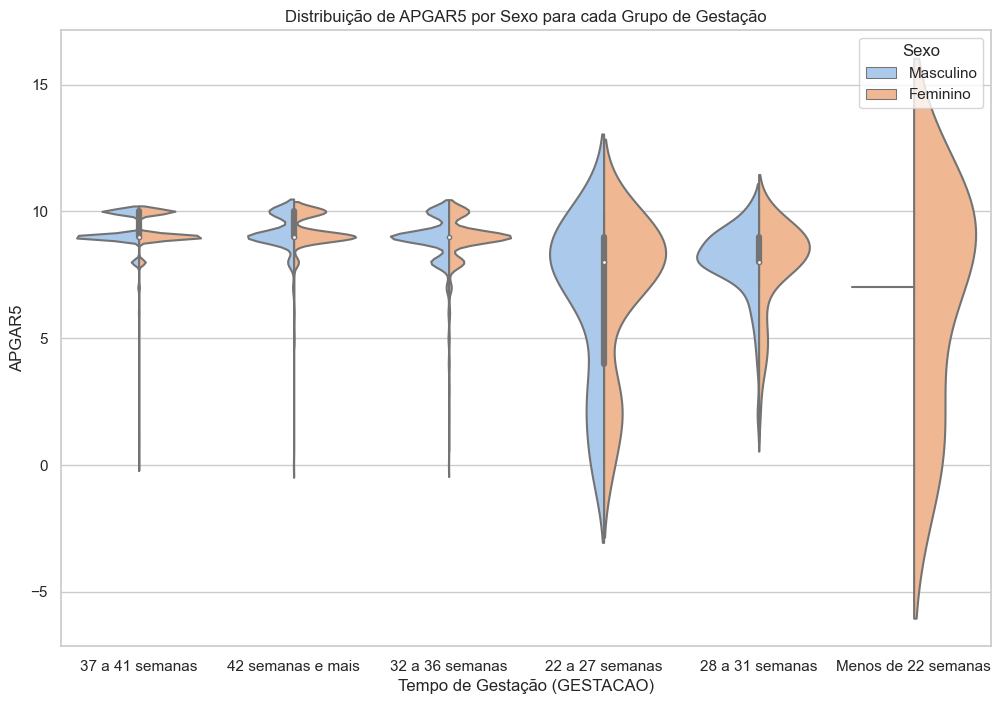

In [10]:
sns.set(style="whitegrid")

# Criando um gráfico de violino
plt.figure(figsize=(12, 8))
sns.violinplot(x='GESTACAO', y='APGAR5', hue='SEXO', data=df, split=True, palette='pastel')
plt.title('Distribuição de APGAR5 por Sexo para cada Grupo de Gestação')
plt.xlabel('Tempo de Gestação (GESTACAO)')
plt.ylabel('APGAR5')
plt.legend(title='Sexo', loc='upper right')
plt.show()

####  4) Monte uma tabela cruzada com APGAR5 nas colunas e GESTACAO nas linhas

In [11]:
tabela_cruzada = pd.crosstab(df['GESTACAO'], df['APGAR5'], margins=True, margins_name='Total')

# Exibindo a tabela cruzada
print(tabela_cruzada)

APGAR5               0.0  1.0  2.0  3.0  4.0  5.0  6.0  7.0   8.0    9.0  \
GESTACAO                                                                   
22 a 27 semanas        7    0    8    6    1    0    2   10    24     19   
28 a 31 semanas        0    0    2    1    5    7    7   11    61     55   
32 a 36 semanas        2    2    2    2    8   11   17   56   362   1307   
37 a 41 semanas        5   20    3    5    7   21   45  151  1417  13565   
42 semanas e mais      1    0    0    0    0    1    1    5    44    423   
Menos de 22 semanas    1    0    1    0    0    0    0    1     0      3   
Total                 16   22   16   14   21   40   72  234  1908  15372   

APGAR5               10.0  Total  
GESTACAO                          
22 a 27 semanas         8     85  
28 a 31 semanas        13    162  
32 a 36 semanas       465   2234  
37 a 41 semanas      7284  22523  
42 semanas e mais     223    698  
Menos de 22 semanas     1      7  
Total                7994  25709  


####  5) Da tabela cruzada do intem anterior, calcule os percentuais de linha. Ou seja, a distribuição da variável APGAR5 para cada classe de GESTACAO dado.

In [12]:
# Calculando os percentuais de linha
tabela_cruzada_percentual = tabela_cruzada.div(tabela_cruzada['Total'], axis=0) * 100

# Exibindo a tabela cruzada com os percentuais de linha
print(tabela_cruzada_percentual)

APGAR5                     0.0       1.0        2.0       3.0       4.0  \
GESTACAO                                                                  
22 a 27 semanas       8.235294  0.000000   9.411765  7.058824  1.176471   
28 a 31 semanas       0.000000  0.000000   1.234568  0.617284  3.086420   
32 a 36 semanas       0.089526  0.089526   0.089526  0.089526  0.358102   
37 a 41 semanas       0.022200  0.088798   0.013320  0.022200  0.031079   
42 semanas e mais     0.143266  0.000000   0.000000  0.000000  0.000000   
Menos de 22 semanas  14.285714  0.000000  14.285714  0.000000  0.000000   
Total                 0.062235  0.085573   0.062235  0.054456  0.081683   

APGAR5                    5.0       6.0        7.0        8.0        9.0  \
GESTACAO                                                                   
22 a 27 semanas      0.000000  2.352941  11.764706  28.235294  22.352941   
28 a 31 semanas      4.320988  4.320988   6.790123  37.654321  33.950617   
32 a 36 semanas     

####  6) Os médicos costumam classificar parto prematuro quando a gestação tem menos que 37 semanas. Faça um gráfico de barras da tabela cruzada acima e conclua se você acha que este conjunto de dados corrobora ou não com a afirmação dos médicos.

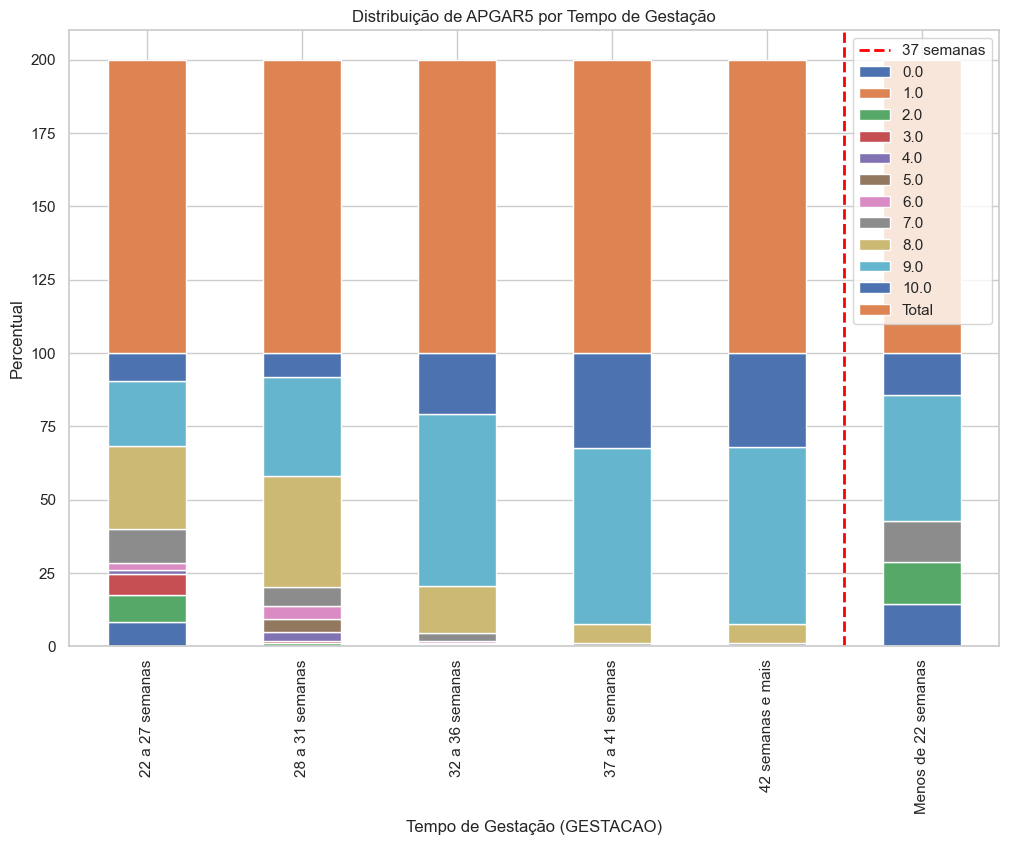

In [13]:
# Carregando os dados do nascidos vivos
df = pd.read_csv('sinasc_RO_2019.csv')

# Criando uma tabela cruzada
tabela_cruzada = pd.crosstab(df['GESTACAO'], df['APGAR5'], margins=True, margins_name='Total')

# Calculando os percentuais de linha
tabela_cruzada_percentual = tabela_cruzada.div(tabela_cruzada['Total'], axis=0) * 100

# Removendo a linha "Total" para o gráfico de barras
tabela_cruzada_percentual = tabela_cruzada_percentual.iloc[:-1, :]

# Criando um gráfico de barras empilhadas
ax = tabela_cruzada_percentual.plot(kind='bar', stacked=True, figsize=(12, 8))
ax.set_title('Distribuição de APGAR5 por Tempo de Gestação')
ax.set_xlabel('Tempo de Gestação (GESTACAO)')
ax.set_ylabel('Percentual')
ax.legend(title='APGAR5', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionando anotações para destacar a gestação prematura (< 37 semanas)
plt.axvline(x=4.5, color='red', linestyle='--', linewidth=2, label='37 semanas')
plt.legend()

plt.show()

É notável que o percentual de recém-nascidos em APGAR 10 e 9 reduzem com menos de 37 semanas. Com 32 semanas a escala APGAR 8 aumenta, tomando parte do que seriam 10, mas 8 ainda é considerado saudavel, já existe um algum percentual de APGAR 7, que indica uma asfixia leve. 

#### 7) Veja se há relação entre APGAR5 e o peso do bebê. Isso pode ser feito de diversas formas. Fique à vontade para escolher a melhor maneira na sua opinião, ou até testar mais de um dos gráficos que vimos. Fique à vontade também para consultar a documentação e utilizar algum outro recurso se achar conveniente.

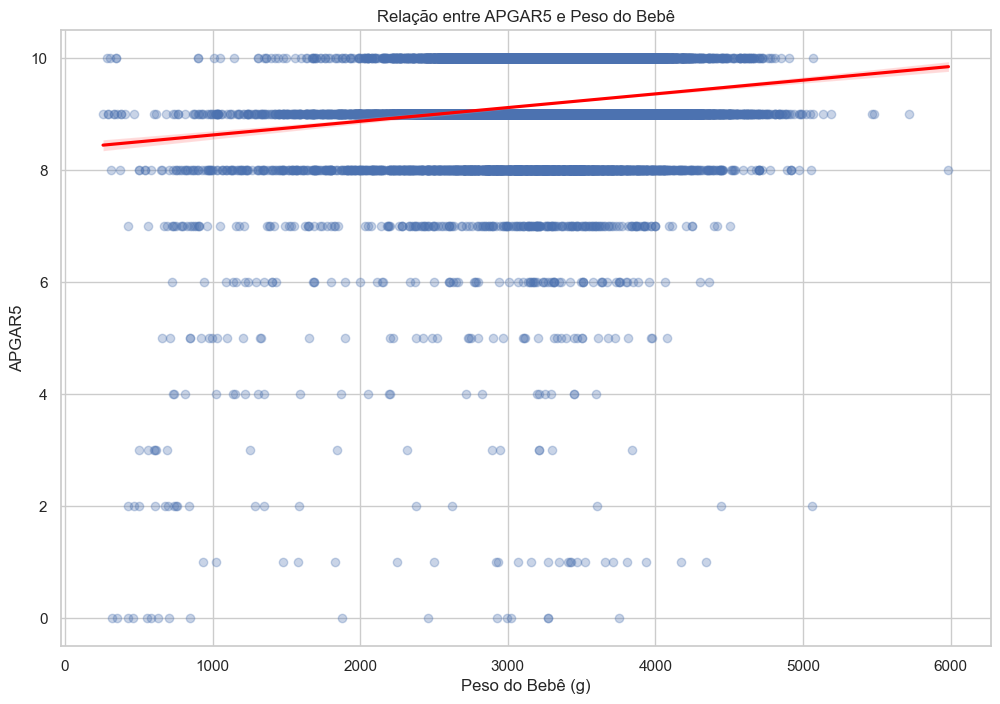

Correlação entre APGAR5 e Peso do Bebê: 0.16821001802434452


In [14]:
plt.figure(figsize=(12, 8))
sns.regplot(x='PESO', y='APGAR5', data=df, scatter_kws={'alpha':0.3}, line_kws={'color': 'red'})
plt.title('Relação entre APGAR5 e Peso do Bebê')
plt.xlabel('Peso do Bebê (g)')
plt.ylabel('APGAR5')
plt.show()

# Calculando a correlação
correlacao_apgar_peso = df['APGAR5'].corr(df['PESO'])
print(f"Correlação entre APGAR5 e Peso do Bebê: {correlacao_apgar_peso}")